In [16]:
import numpy as np

class SVM(object):
    def __init__(self, eta=0.01, n_iter=1000, C=1.0, random_state=1, tol=1e-4, verbose=False):
        self.eta = eta  # Learning rate
        self.n_iter = n_iter  # Number of iterations
        self.C = C  # Regularization parameter
        self.random_state = random_state
        self.tol = tol  # Tolerance for early stopping
        self.verbose = verbose  # Print iterations
    
    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.last_cost = None
        
        for count in range(self.n_iter):
            cost = 0
            for xi, yi in zip(X, y):
                margin = yi * (np.dot(xi, self.w_[1:]) + self.w_[0])
                
                if margin >= 1:
                    self.w_[1:] -= self.eta * self.w_[1:] 
                else:
                    self.w_[1:] -= self.eta * (self.w_[1:] - self.C * yi * xi)  
                    self.w_[0] -= self.eta * (-self.C * yi)
                
                cost += max(0, 1 - margin)  
            
            if self.last_cost is not None and abs(cost - self.last_cost) < self.tol:
                if self.verbose:
                    print(f'Uscita anticipata dopo {count} iterazioni')
                break
            self.last_cost = cost
        
        return self
    
    def predict(self, X):
        return np.where(np.dot(X, self.w_[1:]) + self.w_[0] >= 0, 1, -1)

# Classificazione di Dataset Sbilanciati con SVM

Si vuole affrontare il problema della classificazione di dataset sbilanciati, costituiti da due classi:

- classe `0` (maggioritaria),
- classe `1` (minoritaria).

Si consideri un dataset sintetico con forte sbilanciamento (ad esempio 95% dei campioni appartenenti alla classe `0` e 5% alla classe `1`).


## SVM lineare standard

La SVM lineare usa la formulazione soft-margin:

$$
\frac{1}{2}\|w\|^2 + C \sum_i \xi_i
$$

Il primo termine controlla la norma dei pesi e quindi il margine.

Il secondo termine penalizza le violazioni del margine.

Il parametro $C$ controlla quanto vengono penalizzati gli errori.

In questa prima versione, $C$ è uguale per tutti i campioni.

Quindi un errore su un campione della classe maggioritaria e un errore su un campione della classe minoritaria hanno lo stesso peso.

## Etichette attese dalla SVM

Questa implementazione della SVM usa etichette:

$$
y \in \{-1, +1\}
$$

Il margine viene calcolato come:

$$
y_i(w \cdot x_i + w_0)
$$

Se il margine è almeno 1, il punto è classificato correttamente e rispetta il margine.

Se il margine è minore di 1, il punto viola il margine oppure è classificato male.

Per questo motivo, se il dataset genera etichette `0` e `1`, bisogna convertirle in `-1` e `+1`.


---

## 1. Bilanciamento dei dati per training e validazione

1. Generare un dataset sintetico di classificazione binaria.

## Generazione del dataset sbilanciato

Il dataset è binario e contiene due classi.

Lo sbilanciamento viene introdotto con:

```python
weights=[0.9, 0.1]
```

Quindi circa il 90% degli esempi appartiene alla classe maggioritaria e circa il 10% alla classe minoritaria.

La funzione `make_classification` produce inizialmente etichette `0` e `1`.

Per usare la SVM manuale, le etichette vengono convertite:

```python
y = np.where(y == 0, -1, 1)
```

Quindi:

```text
classe 0 originale -> -1
classe 1 originale -> +1
```

Nota: `flip_y=0.1` introduce rumore nelle etichette. Quindi circa il 10% delle etichette può essere modificato casualmente.

In [17]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000,        # numero di campioni
    n_features=5,          # due feature per visualizzare facilmente
    n_informative=5,       # entrambe informative
    n_redundant=0,         # nessuna feature ridondante
    n_repeated=0,          # nessuna feature duplicata
    n_classes=2,           # classificazione binaria
    n_clusters_per_class=1,# un solo cluster per classe
    class_sep=2.0,         # maggiore separazione tra le classi
    flip_y=0.1,              # nessun rumore nelle etichette
    random_state=50,
    weights=[0.9, 0.1],  # 90% classe 0, 10% classe 1
)

y = np.where(y == 0, -1, 1) # per compatibilità con nostro svm


2. Suddividere il dataset in:
   - training set,
   - test set.

## Training set e test set

Il dataset viene diviso in:

- training set;
- test set.

Il training set viene usato per costruire i modelli e scegliere gli iperparametri.

Il test set viene lasciato da parte fino alla valutazione finale.

Nel caso dei dataset sbilanciati, il test set deve mantenere la distribuzione originale delle classi.

Questo è importante perché il test deve simulare il caso reale.

In [18]:
import numpy as np
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)


3. **A partire dal training set, estrarre inizialmente un sottoinsieme bilanciato**, selezionando casualmente lo stesso numero di campioni per ciascuna classe, pari al numero di campioni della classe minoritaria.

## Bilanciamento esplicito del training set

La prima strategia consiste nel bilanciare il training set.

La tecnica usata è l'undersampling della classe maggioritaria.

L'idea è:

```text
1. identificare la classe minoritaria;
2. tenere tutti i campioni della classe minoritaria;
3. selezionare casualmente dalla classe maggioritaria lo stesso numero di campioni;
4. costruire un training set bilanciato.
```

Il test set non viene bilanciato.

Il training set può essere modificato per aiutare il modello ad apprendere meglio la classe minoritaria.

Il test set deve invece rimanere sbilanciato per valutare le prestazioni in modo realistico.

In [19]:
# indici delle classi
idx_0 = np.where(y_train_full == -1)[0]
idx_1 = np.where(y_train_full == 1)[0]

# classe minoritaria (troviamo quale è più piccola)
minority_class = 1 if len(idx_1) < len(idx_0) else -1

minority_idx = np.where(y_train_full == minority_class)[0]
majority_idx = np.where(y_train_full != minority_class)[0]

# prendi solo N campioni dalla maggioritaria
np.random.seed(1)
majority_sample = np.random.choice(
    majority_idx,
    size=len(minority_idx),
    replace=False
)

# unisci
balanced_idx = np.concatenate([minority_idx, majority_sample])

# nuovo training set bilanciato
X_train_bal = X_train_full[balanced_idx]
y_train_bal = y_train_full[balanced_idx]

## Effetto dell'undersampling

Dopo l'undersampling, il training set contiene circa lo stesso numero di esempi per ciascuna classe.

Questo evita che il modello sia dominato dalla classe maggioritaria.

Lo svantaggio è che molti esempi della classe maggioritaria vengono scartati.

Quindi:

```text
vantaggio:
training più bilanciato

svantaggio:
perdita di informazione dalla classe maggioritaria
```

Se il dataset diventa troppo piccolo, il modello può avere maggiore varianza.

## Cross validation sul training bilanciato

La cross validation viene applicata a:

```python
X_train_bal, y_train_bal
```

Quindi viene usato il training set già bilanciato.

Viene usata una `StratifiedKFold` a 4 fold.

Per ogni valore di `C`:

```text
1. il training bilanciato viene diviso in fold;
2. il modello viene addestrato su una parte dei fold;
3. viene validato sul fold rimanente;
4. si salva l'accuracy;
5. si calcola la media delle accuracy sui fold.
```

Il valore di `C` con accuracy media più alta viene scelto come migliore.

Il test set non viene usato in questa fase.

In [20]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

kf = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)

# ==========================================================
# Iperparametri da testare
# ==========================================================
C_values = [0.05, 0.1, 1]

best_score = 0
best_params = None

# ==========================================================
# Loop sugli iperparametri
# ==========================================================
for C in C_values:
    fold_scores = []

    # ======================================================
    # Cross-validation
    # ======================================================
    for train_idx, val_idx in kf.split(X_train_bal, y_train_bal):

        X_train, X_val = X_train_bal[train_idx], X_train_bal[val_idx]
        y_train, y_val = y_train_bal[train_idx], y_train_bal[val_idx]

        model = SVM(eta=0.001, C=C)

        model.fit(X_train, y_train)
        preds = model.predict(X_val)

        acc = np.mean(y_val==preds)

        fold_scores.append(acc)

    mean_score = np.mean(fold_scores)

    print(f"C={C} -> CV accuracy = {mean_score:.4f}")

    if mean_score > best_score:
        best_score = mean_score
        best_params = (C,)

C=0.05 -> CV accuracy = 0.8155
C=0.1 -> CV accuracy = 0.8155
C=1 -> CV accuracy = 0.8155


## Scelta di C

Il parametro `C` controlla quanto la SVM penalizza le violazioni del margine.

Valori piccoli di `C` rendono il modello più regolarizzato.

Valori grandi di `C` rendono il modello più sensibile agli errori sul training set.

Nel codice vengono provati:

```python
C_values = [0.05, 0.1, 1]
```

La nota della lezione suggerisce che potrebbe essere utile provare anche valori maggiori di `1`.

Questo perché il valore migliore potrebbe trovarsi fuori dalla griglia iniziale.

In [21]:
# ==========================================================
# Migliori iperparametri
# ==========================================================
print("\nMigliori iperparametri trovati:")
print("C =", best_params[0])
print("CV accuracy media =", best_score)


Migliori iperparametri trovati:
C = 0.05
CV accuracy media = 0.8155165912518854


## Addestramento finale

Dopo aver scelto il valore migliore di `C`, il modello finale viene addestrato su tutto il training set bilanciato:

```python
X_train_bal, y_train_bal
```

Il training set è bilanciato perché l'obiettivo è evitare che la SVM impari a favorire troppo la classe maggioritaria.

Il test set resta invece sbilanciato.

Questa distinzione è fondamentale:

```text
training bilanciato:
utile per apprendere meglio entrambe le classi

test sbilanciato:
utile per valutare il comportamento nel caso reale
```

In [22]:
# ==========================================================
# Modello finale su tutto il dataset
# ==========================================================
final_model = SVM(
    eta=0.001, # poteva valere la pena variare anche questo
    C=best_params[0],
)

final_model.fit(X_train_bal, y_train_bal)

print("\nModello finale addestrato su tutto il dataset.")


Modello finale addestrato su tutto il dataset.


## Valutazione finale

La valutazione viene fatta sul test set originale.

L'accuracy viene calcolata, ma non è sufficiente per giudicare il modello.

Nei dataset sbilanciati bisogna osservare anche la matrice di confusione.

Da essa ricaviamo:

- true negative;
- false positive;
- false negative;
- true positive.

Poi calcoliamo:

$$
Precision = \frac{TP}{TP + FP}
$$

e:

$$
Recall = \frac{TP}{TP + FN}
$$

La recall è particolarmente importante quando la classe positiva è minoritaria, perché misura quanti positivi reali vengono riconosciuti.

Test accuracy finale: 0.9433333333333334


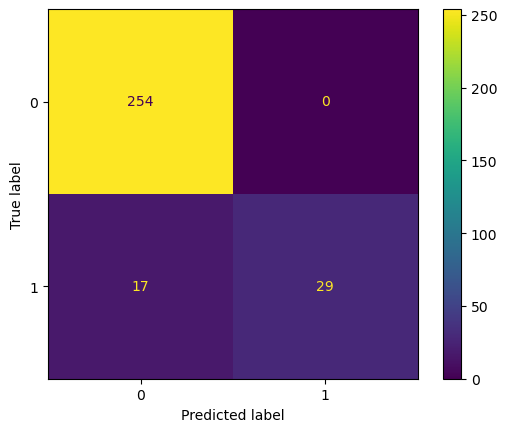


Precision: 1.0
Recall: 0.6304347826086957


In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ==========================================================
# TEST FINALE (mai usato prima)
# ==========================================================
test_pred = final_model.predict(X_test)
test_acc = np.mean(y_test==test_pred)

print("Test accuracy finale:", test_acc)

cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()

precision = tp / (tp + fp) # frazione di positivi trovati  tra tutti i predetti positivi
recall = tp / (tp + fn) # frazione di positivi trovati tra tutti i positivi reali

print("\nPrecision:", precision)
print("Recall:", recall)

## Limite della strategia con undersampling

L'undersampling riduce il numero di esempi della classe maggioritaria.

Questo rende il training set bilanciato, ma può eliminare informazioni utili.

Se vengono scartati molti esempi, il modello viene addestrato su un dataset più piccolo.

Questo può aumentare la varianza.

Per questo motivo è utile confrontare questa strategia con un approccio diverso:

```text
mantenere il dataset sbilanciato
ma pesare di più gli errori sulla classe minoritaria
```

Questa è l'idea della SVM con pesi di classe.

## 2. Modifica dell'implementazione della SVM


Si consideri la formulazione soft-margin della SVM:

$$
\frac{1}{2}\|w\|^2
+
C\sum_{i=1}^{N}\xi_i
$$

Modificare l'implementazione sostituendo il parametro globale `C` con un parametro specifico per ciascun campione:

$$
C_i = C \cdot v_{i}
$$

dove:

- $v_{i}$ è il peso associato alla classe del campione $i$,

I pesi di classe sono definiti come inversamente proporzionali alla frequenza delle classi nel training set:

$$
v_c = \frac{n}{2n_c}
$$

dove:

- $n$ è il numero totale di campioni del training set,
- $n_c$ è il numero di campioni appartenenti alla classe $c$.

In questo modo:

- la classe maggioritaria riceve un peso minore;
- la classe minoritaria riceve un peso maggiore;
- gli errori sui campioni della classe minoritaria vengono penalizzati maggiormente.

### Con `sklearn`

`sklearn` permette di gestire automaticamente i dataset sbilanciati tramite:

```python
class_weight="balanced"
```

Questo parametro assegna pesi inversamente proporzionali alla frequenza delle classi:

$$
\frac{n_{samples}}{n_{classes} \cdot n_c}
$$

dove $n_c$ è il numero di esempi della classe $c$.

Il significato è lo stesso della SVM pesata implementata manualmente:

```text
classe frequente -> peso minore
classe rara      -> peso maggiore
```

In [25]:
class SVM(object):
    def __init__(self, eta=0.01, n_iter=1000, C=1.0, random_state=1, tol=1e-4, verbose=False):
        self.eta = eta  # Learning rate
        self.n_iter = n_iter  # Number of iterations
        self.C = C  # Regularization parameter
        self.random_state = random_state
        self.tol = tol  # Tolerance for early stopping
        self.verbose = verbose  # Print iterations
    
    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.last_cost = None
        
        n0 = len(np.where(y == -1)[0])
        n1 = len(np.where(y == 1)[0])
        n = len(y)

        for count in range(self.n_iter):
            cost = 0
            for xi, yi in zip(X, y):
                margin = yi * (np.dot(xi, self.w_[1:]) + self.w_[0])
                
                if margin >= 1:
                    self.w_[1:] -= self.eta * self.w_[1:] 
                else:
                    ni = n1 if yi == 1 else n0
                    Ci = self.C*n/(2*ni)
                    self.w_[1:] -= self.eta * (self.w_[1:] - Ci * yi * xi)  
                    self.w_[0] -= self.eta * (Ci * yi)
                
                cost += max(0, 1 - margin)  
            
            if self.last_cost is not None and abs(cost - self.last_cost) < self.tol:
                if self.verbose:
                    print(f'Uscita anticipata dopo {count} iterazioni')
                break
            self.last_cost = cost
        
        return self
    
    def predict(self, X):
        return np.where(np.dot(X, self.w_[1:]) + self.w_[0] >= 0, 1, -1)

In [26]:
kf = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)

# ==========================================================
# Iperparametri da testare
# ==========================================================
C_values = [0.05, 0.1, 1]

best_score = 0
best_params = None

# ==========================================================
# Loop sugli iperparametri
# ==========================================================
for C in C_values:
    fold_scores = []

    # ======================================================
    # Cross-validation
    # ======================================================
    for train_idx, val_idx in kf.split(X_train_full, y_train_full):

        X_train, X_val = X_train_full[train_idx], X_train_full[val_idx]
        y_train, y_val = y_train_full[train_idx], y_train_full[val_idx]

        model = SVM(eta=0.001, C=C)

        model.fit(X_train, y_train)
        preds = model.predict(X_val)


        acc = np.mean(y_val==preds)

        fold_scores.append(acc)

    mean_score = np.mean(fold_scores)

    print(f"C={C} -> CV accuracy = {mean_score:.4f}")

    if mean_score > best_score:
        best_score = mean_score
        best_params = (C,)

C=0.05 -> CV accuracy = 0.9414
C=0.1 -> CV accuracy = 0.1471
C=1 -> CV accuracy = 0.1471



Modello finale addestrato su tutto il dataset.
Test accuracy finale: 0.9433333333333334


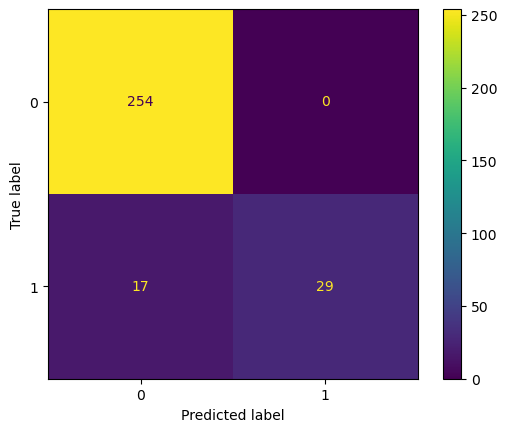


Precision: 1.0
Recall: 0.6304347826086957


In [27]:
# ==========================================================
# Modello finale su tutto il dataset
# ==========================================================
final_model = SVM(
    eta=0.001,
    C=best_params[0],
)

final_model.fit(X_train_full, y_train_full)

print("\nModello finale addestrato su tutto il dataset.")


# ==========================================================
# TEST FINALE (mai usato prima)
# ==========================================================
test_pred = final_model.predict(X_test)
test_acc = np.mean(y_test==test_pred)


print("Test accuracy finale:", test_acc)

cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()

precision = tp / (tp + fp) # frazione di positivi trovati  tra tutti i predetti positivi
recall = tp / (tp + fn) # frazione di positivi trovati tra tutti i positivi reali

print("\nPrecision:", precision)
print("Recall:", recall)

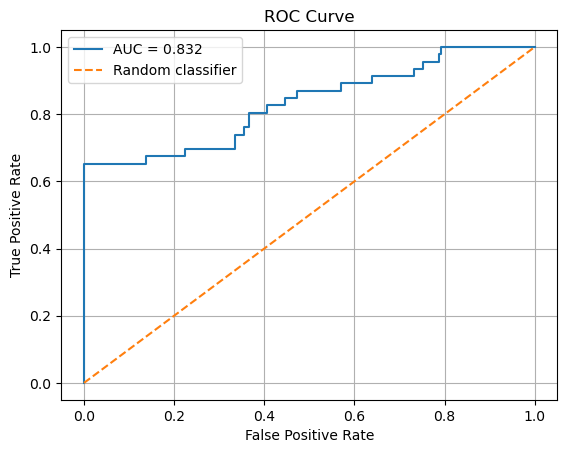

In [24]:
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score

model = SVC(kernel='linear', C=best_params[0], probability=True, class_weight="balanced")
model.fit(X_train_full, y_train_full)

# 4. Probabilità della classe positiva
y_scores = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)

# 6. Plot
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

`probability=True` abilita il calcolo delle probabilità tramite:

```python
predict_proba
```

La riga:

```python
y_scores = model.predict_proba(X_test)[:, 1]
```

estrae la probabilità assegnata alla classe positiva.

Questi score vengono usati per costruire la ROC curve.

La ROC curve mostra il comportamento del classificatore al variare della soglia decisionale.

L'AUC riassume la curva in un solo valore:

```text
AUC vicino a 1   -> buon classificatore
AUC vicino a 0.5 -> comportamento simile al caso casuale
```

## Sovracampionamento

L'oversampling bilancia il training set aumentando il numero di esempi della classe minoritaria.

A differenza dell'undersampling, non elimina esempi della classe maggioritaria.

Due strategie comuni sono:

```text
duplicazione casuale:
copia esempi già esistenti della classe minoritaria

generazione sintetica:
crea nuovi esempi simili a quelli minoritari
```

SMOTE appartiene alla seconda categoria.

### SMOTE

SMOTE genera nuovi punti della classe minoritaria tramite interpolazione.

Per un punto minoritario $x_i$:

1. trova i suoi vicini più prossimi nella classe minoritaria;
2. sceglie casualmente uno di questi vicini;
3. genera un nuovo punto sul segmento tra i due.

La formula intuitiva è:

$$
x_{new} = x_i + \lambda(x_{nn} - x_i)
$$

dove:

- $x_i$ è il punto minoritario di partenza;
- $x_{nn}$ è un vicino minoritario;
- $\lambda$ è un valore casuale tra 0 e 1.

Il nuovo punto non è una semplice copia: è un esempio sintetico intermedio.

### Funzione `smote`

Parametri principali:

```text
X:
matrice degli esempi

y:
etichette

lab:
classe da sovracampionare

n_samples:
numero di nuovi campioni da generare

k:
numero di vicini da considerare

random_seed:
seme per rendere il risultato riproducibile
```

La funzione usa un `KDTree` per cercare velocemente i vicini più prossimi tra i soli esempi della classe minoritaria.

## Descrizione della funzione `smote`

1. **Impostazione del seme casuale**  
   Viene fissato il `random_seed` per rendere riproducibile la generazione dei punti sintetici.

2. **Costruzione del KD‑Tree**  
   Si costruisce un albero KD (`KDTree`) usando solo i campioni la cui etichetta è uguale a `lab`. Questo permette di trovare rapidamente i vicini più prossimi nella classe minoritaria.

3. **Selezione dei “base points”**  
   - Se il numero di esempi minoritari è ≤ `n_samples`, si utilizzano tutti come punti base.  
   - Altrimenti, si estraggono casualmente (senza ripetizione) tanti indici quanti servono per raggiungere `n_samples`.

4. **Costruzione del dizionario dei vicini**  
   Per ciascun punto base, si calcolano i suoi k‑nearest neighbours all’interno dei soli campioni minoritari e si memorizzano gli indici dei vicini in un dizionario.

5. **Generazione dei punti sintetici**  
   - Si cicla fino a ottenere `n_samples` nuovi esempi.  
   - Ad ogni iterazione, si seleziona un punto base (in modalità ciclica) e uno dei suoi vicini in modo casuale.  
   - Si estrae un fattore λ casuale ∈ [0, 1].  
   - Si crea il nuovo punto interpolando linearmente tra il punto base e il vicino scelto.

6. **Restituzione del risultato**  
   La funzione restituisce un array NumPy di forma `(n_samples, n_features)` contenente tutti i punti sintetici generati per la classe `lab`.  

In [28]:
from sklearn.neighbors import KDTree

def smote(X, y, lab, n_samples, k = 5, random_seed = 0):
    '''
    parametri: X, y matrice degli esempi ed etichette
        lab: etichetta da sovracampionare
        n_samples: numero di campioni da generare
        k: numero di vicini da usare per interpolazione
    '''
    np.random.seed(random_seed)
    
    tree = KDTree(X[ y==lab ], leaf_size=2)

    min_lab_idx =np.where(y == lab)[0] # indici dei punti X etichettati con lab
    
    # base_points_idx indici in X dei punti usati per l'intepolazione
    base_points_idx = min_lab_idx if X[ y==lab ].shape[0] <= n_samples \
        else  np.random.choice(min_lab_idx, n_samples, replace = False)
    n_base_points = base_points_idx.shape[0]

    # per ogni punto in base_points_idx calcoliamo i k-nearest neighbors e li inseriamo in un dizionario
    # con chiave l'indice, i vicini sono espressi come indici in X
    knn_dict = {}
    for i in  base_points_idx:
        knn_dict[i] = min_lab_idx[ tree.query([X[i]], k=k)[1] ] [0] # query ritorna una matrice
    
    new_points = []

    for i in range(n_samples):
        cur_base_point_idx = base_points_idx[i % n_base_points]
        xi = X[cur_base_point_idx]

        nn_idx = np.random.choice( knn_dict[cur_base_point_idx],  1)[0] # choice ritorna un array
        lmbd = np.random.rand()

        nn = X[nn_idx]
        ip = xi+lmbd*(nn-xi)
        new_points.append(ip)
    
    return np.array(new_points)

La funzione lavora solo sui campioni con etichetta uguale a `lab`.

Questa riga costruisce il KDTree sui campioni della classe da sovracampionare:

```python
tree = KDTree(X[y == lab], leaf_size=2)
```

Questa riga trova gli indici dei campioni appartenenti a quella classe:

```python
min_lab_idx = np.where(y == lab)[0]
```

Per ogni punto base vengono calcolati i vicini più prossimi.

Poi ogni nuovo campione viene generato con:

```python
ip = xi + lmbd * (nn - xi)
```

cioè tramite interpolazione tra il punto base `xi` e un vicino `nn`.

In [29]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

# indici delle classi
idx_0 = np.where(y_train_full == -1)[0]
idx_1 = np.where(y_train_full == 1)[0]

# classe minoritaria (troviamo quale è più piccola)
minority_class = 1 if len(idx_1) < len(idx_0) else -1

minority_idx = np.where(y_train_full == minority_class)[0]
majority_idx = np.where(y_train_full != minority_class)[0]

new_samples = smote(X_train_full, y_train_full, minority_class, len(majority_idx)-len(minority_idx))

# nuovo training set bilanciato
X_train_bal = np.concatenate( [X_train_full, new_samples])
y_train_bal = np.concatenate( [y_train_full, np.array([minority_class]*len(new_samples))])

`new_samples` contiene i campioni sintetici generati per la classe minoritaria.

Il numero di nuovi campioni è:

```python
len(majority_idx) - len(minority_idx)
```

cioè il numero necessario per rendere la classe minoritaria numericamente pari alla maggioritaria.

Il nuovo training set viene costruito concatenando:

```text
training originale
+
campioni sintetici della classe minoritaria
```

Il test set resta invariato.

In [30]:
kf = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)

# ==========================================================
# Iperparametri da testare
# ==========================================================
C_values = [0.05, 0.1, 1]

best_score = 0
best_params = None

# ==========================================================
# Loop sugli iperparametri
# ==========================================================
for C in C_values:
    fold_scores = []

    # ======================================================
    # Cross-validation
    # ======================================================
    for train_idx, val_idx in kf.split(X_train_bal, y_train_bal):

        X_train, X_val = X_train_bal[train_idx], X_train_bal[val_idx]
        y_train, y_val = y_train_bal[train_idx], y_train_bal[val_idx]

        model = SVM(eta=0.001, C=C)

        model.fit(X_train, y_train)
        preds = model.predict(X_val)


        acc = np.mean(y_val==preds)

        fold_scores.append(acc)

    mean_score = np.mean(fold_scores)

    print(f"C={C} -> CV accuracy = {mean_score:.4f}")

    if mean_score > best_score:
        best_score = mean_score
        best_params = (C,)

C=0.05 -> CV accuracy = 0.8107
C=0.1 -> CV accuracy = 0.5000
C=1 -> CV accuracy = 0.5000


La procedura è la stessa usata con undersampling.

La differenza è nel modo in cui viene creato `X_train_bal`.

Con undersampling:

```text
si riduce la classe maggioritaria
```

Con SMOTE:

```text
si aumenta la classe minoritaria con campioni sintetici
```

La cross validation viene fatta sul training bilanciato ottenuto tramite SMOTE.


Modello finale addestrato su tutto il dataset.
Test accuracy finale: 0.9166666666666666


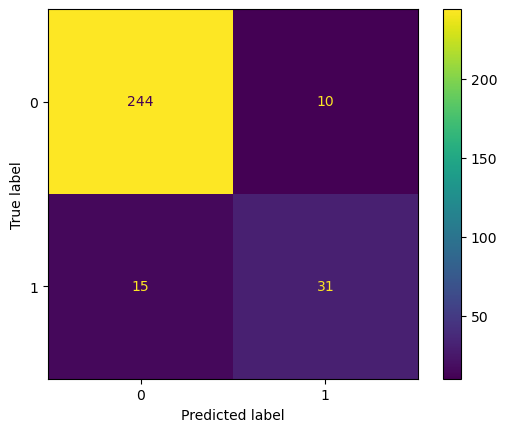


Precision: 0.7560975609756098
Recall: 0.6739130434782609
300


In [31]:
# ==========================================================
# Modello finale su tutto il dataset
# ==========================================================
final_model = SVM(
    eta=0.001,
    C=best_params[0],
)

final_model.fit(X_train_bal, y_train_bal)

print("\nModello finale addestrato su tutto il dataset.")


# ==========================================================
# TEST FINALE (mai usato prima)
# ==========================================================
test_pred = final_model.predict(X_test)
test_acc = np.mean(y_test==test_pred)


print("Test accuracy finale:", test_acc)

cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()

precision = tp / (tp + fp) # frazione di positivi trovati  tra tutti i predetti positivi
recall = tp / (tp + fn) # frazione di positivi trovati tra tutti i positivi reali

print("\nPrecision:", precision)
print("Recall:", recall)

print(len(y_test))

Il modello finale viene addestrato sul training bilanciato con SMOTE.

La valutazione rimane sul test set originale.

La matrice di confusione serve a capire se il modello sta migliorando il riconoscimento della classe minoritaria oppure se sta aumentando troppo i falsi positivi.

Il valore di `print(len(y_test))` controlla semplicemente la dimensione del test set.

### Con `sklearn`

Dopo aver creato il training bilanciato con SMOTE, viene addestrata una SVM di `sklearn`.

Il modello usa ancora:

```python
class_weight="balanced"
```

Quindi combina due idee:

```text
training bilanciato tramite SMOTE
+
pesi di classe automatici
```

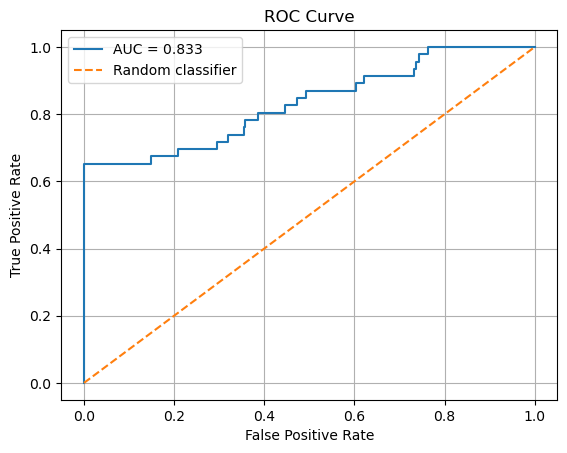

In [32]:
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score

model = SVC(kernel='linear', C=best_params[0], probability=True, class_weight="balanced")
model.fit(X_train_bal, y_train_bal)

# 4. Probabilità della classe positiva
y_scores = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)

# 6. Plot
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

# Classificazione multiclasse con classificatore binario - One-vs-Rest

Alcuni classificatori nascono come classificatori binari.

Una SVM binaria, per esempio, separa due classi:

```text
classe positiva
classe negativa
```

Nel caso multiclasse, invece, le classi possibili sono più di due.

Esempio:

```text
classe 0
classe 1
classe 2
```

Una strategia per usare comunque classificatori binari è One-vs-Rest, abbreviato OvR.

## Idea di One-vs-Rest

Con One-vs-Rest si addestra un classificatore binario per ogni classe.

Ogni classificatore distingue:

```text
una classe specifica
contro
tutte le altre classi
```

Se abbiamo 3 classi:

```text
0, 1, 2
```

allora costruiamo 3 classificatori binari:

```text
modello 0:
classe 0 vs classi 1 e 2

modello 1:
classe 1 vs classi 0 e 2

modello 2:
classe 2 vs classi 0 e 1
```

Se abbiamo `k` classi, addestriamo `k` modelli binari.

## Etichette binarie per ogni modello

Per addestrare il modello della classe `c`, le etichette vengono trasformate così:

```python
y_binary = (y == c).astype(int)
```

Quindi:

```text
gli esempi della classe c diventano 1
gli esempi di tutte le altre classi diventano 0
```

Esempio con classe corrente `c = 1`:

```text
y originale:
[0, 1, 2, 1, 0, 2]

y_binary:
[0, 1, 0, 1, 0, 0]
```

Il modello impara quindi a riconoscere la classe `1` contro tutto il resto.

In [33]:
import numpy as np
from sklearn.svm import SVC

class OneVsRestSVM:
    def __init__(self, kernel="linear", C=1.0):
        self.kernel = kernel
        self.C = C
        self.models_ = {}

    def fit(self, X, y):
        """
        Addestra un SVM binario per ogni classe (classe vs resto).
        """
        self.classes_ = np.unique(y)

        for c in self.classes_:
            # trasformazione binaria: classe c vs resto
            y_binary = (y == c).astype(int)

            model = SVC(
                kernel=self.kernel,
                C=self.C,
            )

            model.fit(X, y_binary)
            self.models_[c] = model

        return self

    def predict(self, X):
        # matrice (n_classes, n_samples)
        scores = np.vstack([
            model.decision_function(X)
            for model in self.models_.values()
        ])

        # argmax sulle classi
        best_class_indices = np.argmax(scores, axis=0)

        return self.classes_[best_class_indices]

## Metodo `fit`

Il metodo `fit` estrae tutte le classi presenti nel dataset:

```python
self.classes_ = np.unique(y)
```

Poi scorre ogni classe:

```python
for c in self.classes_:
```

Per ogni classe costruisce un problema binario:

```python
y_binary = (y == c).astype(int)
```

Il classificatore corrente considera positivi solo gli esempi della classe `c`.

Tutti gli altri esempi sono considerati negativi.

Ogni modello viene salvato nel dizionario:

```python
self.models_[c] = model
```

La chiave è la classe originale, il valore è la SVM binaria addestrata per quella classe.

## Metodo `predict`

Durante la predizione, tutti i modelli binari producono uno score per ogni esempio.

La riga:

```python
model.decision_function(X)
```

restituisce la distanza dei punti dalla frontiera decisionale del modello binario.

Uno score più alto indica che il modello è più convinto che il punto appartenga alla propria classe positiva.

Gli score di tutti i modelli vengono impilati in una matrice:

```python
scores = np.vstack([...])
```

La matrice ha forma:

```text
numero_classi x numero_esempi
```

Per ogni esempio si sceglie la classe del modello che ha prodotto lo score massimo:

```python
best_class_indices = np.argmax(scores, axis=0)
```

Infine gli indici vengono riconvertiti nelle classi originali:

```python
return self.classes_[best_class_indices]
```

## Esempio di scelta della classe

Supponiamo di avere tre modelli OvR:

```text
modello classe 0
modello classe 1
modello classe 2
```

Per un certo esempio, gli score sono:

```text
classe 0: -0.8
classe 1:  1.4
classe 2:  0.2
```

La classe scelta è quella con lo score più alto:

```text
classe 1
```

Quindi OvR non sceglie semplicemente il primo modello che dice positivo.

Confronta gli score prodotti da tutti i classificatori e prende il massimo.

In [34]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# dataset 3 classi
X, y = make_classification(
    n_samples=1500,
    n_features=5,
    n_informative=5,
    n_redundant=0,
    n_classes=3,
    n_clusters_per_class=1,
    class_sep=2.0,
    random_state=1
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=1
)

model = OneVsRestSVM(kernel="rbf", C=1.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = np.mean(y_pred == y_test)
print("Accuracy:", accuracy)

Accuracy: 0.9844444444444445


## Dataset a tre classi

Il dataset viene generato con:

```python
n_classes=3
```

Quindi il problema non è più binario.

Le classi possibili sono:

```text
0, 1, 2
```

Il modello `OneVsRestSVM` trasforma il problema in tre problemi binari.

Con:

```python
model = OneVsRestSVM(kernel="rbf", C=1.0)
```

ogni classificatore binario interno è una SVM con kernel RBF.

Dopo il training, la predizione finale viene ottenuta confrontando gli score dei tre modelli.

## Costo computazionale

Se il dataset ha:

- `n` esempi;
- `d` feature;
- `k` classi;

la strategia One-vs-Rest addestra:

$$
k
$$

classificatori binari.

Quindi il costo di training è circa:

$$
k \cdot T_{binario}
$$

dove $T_{binario}$ è il costo di addestramento di un singolo classificatore binario.

In fase di predizione, ogni esempio deve essere valutato da tutti i modelli.

Quindi anche il costo di predizione cresce con il numero di classi:

$$
O(k)
$$

per ogni esempio, oltre al costo della predizione del singolo modello.

## Riassunto One-vs-Rest

One-vs-Rest permette di usare classificatori binari per problemi multiclasse.

Per ogni classe viene addestrato un modello:

```text
classe c
contro
tutte le altre classi
```

In predizione:

```text
ogni modello produce uno score
si sceglie la classe con score massimo
```

Con `k` classi vengono addestrati `k` classificatori binari.

La strategia è semplice e generale, ma il costo cresce con il numero di classi.